In [1]:
import seaborn as sns 
import pandas as pd
import numpy as np

In [2]:
%matplotlib inline 
%config InlineBackend.figure_format = 'retina'

In [3]:
dane = pd.read_csv('housing.csv/housing.csv')

In [4]:
dane.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [5]:
dane[dane['total_bedrooms'].isna()].head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
290,-122.16,37.77,47.0,1256.0,NaN,570.0,218.0,4.3750,161900.0,NEAR BAY
341,-122.17,37.75,38.0,992.0,NaN,732.0,259.0,1.6196,85100.0,NEAR BAY
538,-122.28,37.78,29.0,5154.0,NaN,3741.0,1273.0,2.5762,173400.0,NEAR BAY
563,-122.24,37.75,45.0,891.0,NaN,384.0,146.0,4.9489,247100.0,NEAR BAY
696,-122.10,37.69,41.0,746.0,NaN,387.0,161.0,3.9063,178400.0,NEAR BAY
738,-122.14,37.67,37.0,3342.0,NaN,1635.0,557.0,4.7933,186900.0,NEAR BAY
1097,-121.77,39.66,20.0,3759.0,NaN,1705.0,600.0,4.7120,158600.0,INLAND
1350,-121.95,38.03,5.0,5526.0,NaN,3207.0,1012.0,4.0767,143100.0,INLAND
1456,-121.98,37.96,22.0,2987.0,NaN,1420.0,540.0,3.6500,204100.0,INLAND
1493,-122.01,37.94,23.0,3741.0,NaN,1339.0,499.0,6.7061,322300.0,NEAR BAY


<Axes: >

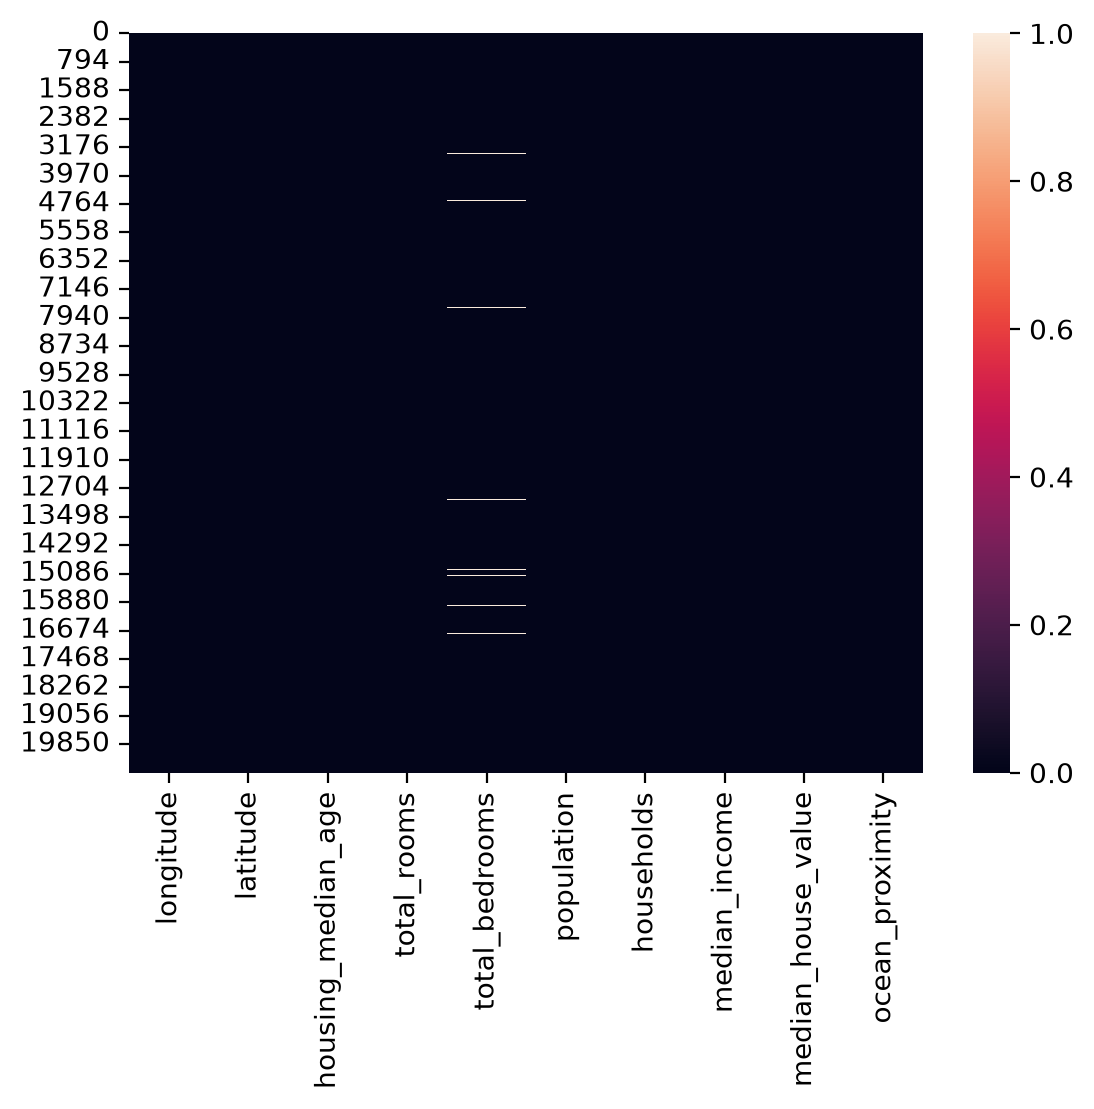

In [6]:
sns.heatmap(dane.isna())

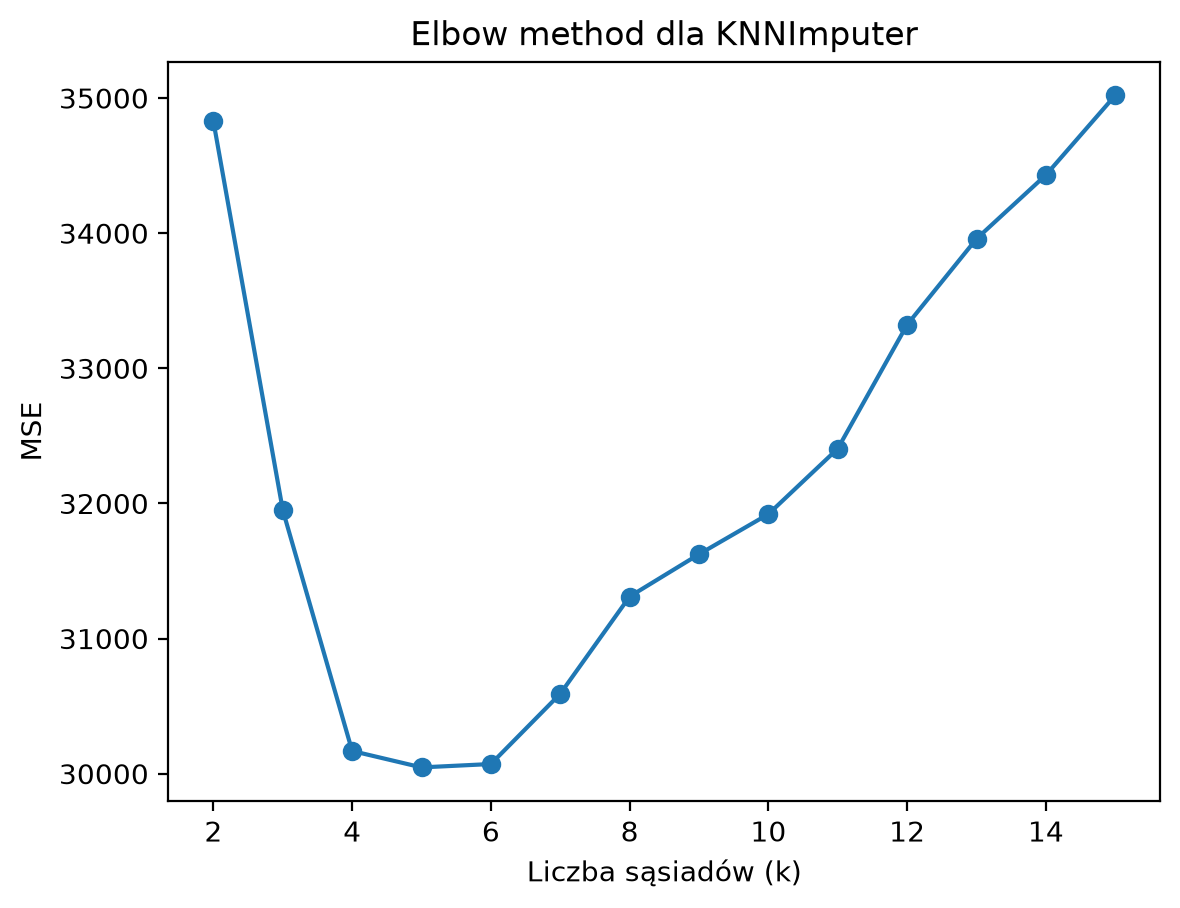

In [7]:
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = dane[['total_bedrooms', 'total_rooms', 'median_income', 'median_house_value']].dropna().copy()
np.random.seed(42)
mask = np.random.rand(len(df)) < 0.2  
df_missing = df.copy()
df_missing.loc[mask, 'total_bedrooms'] = np.nan
errors = []
neighbors = range(2, 16)
for k in neighbors:
    imputer = KNNImputer(n_neighbors=k)
    imputed = imputer.fit_transform(df_missing)
    mse = mean_squared_error(df['total_bedrooms'][mask], imputed[mask, 0])
    errors.append(mse)

plt.plot(neighbors, errors, marker='o')
plt.xlabel('Liczba sąsiadów (k)')
plt.ylabel('MSE')
plt.title('Elbow method dla KNNImputer')
plt.show()

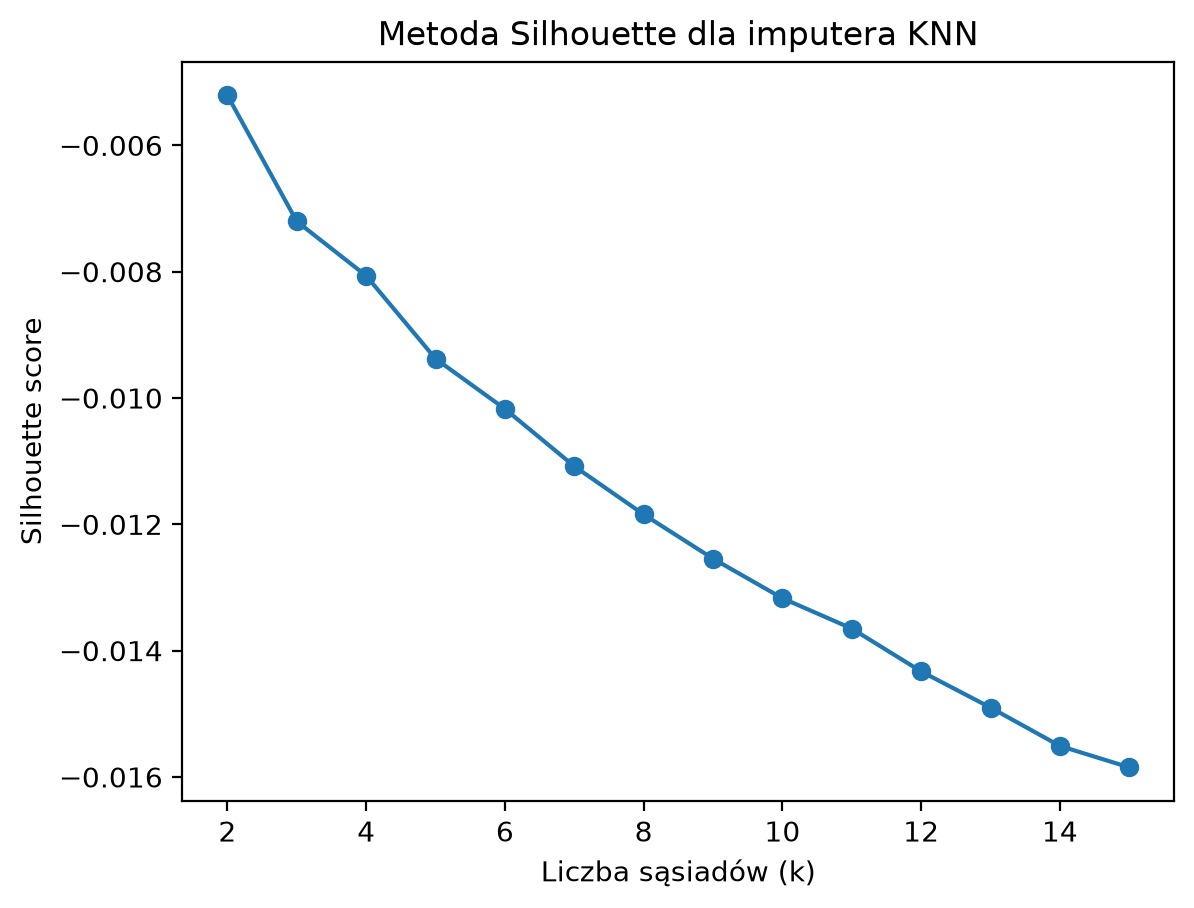

In [8]:
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

df = dane[['total_bedrooms', 'total_rooms', 'median_income', 'median_house_value']].dropna().copy()
np.random.seed(42)
mask = np.random.rand(len(df)) < 0.2 
df_missing = df.copy()
df_missing.loc[mask, 'total_bedrooms'] = np.nan

silhouette_scores = []
neighbors = range(2, 16)
for k in neighbors:
    imputer = KNNImputer(n_neighbors=k)
    imputed = imputer.fit_transform(df_missing)
    
    scaler = StandardScaler()
    imputed_scaled = scaler.fit_transform(imputed)

    labels = np.where(mask, 1, 0)
    score = silhouette_score(imputed_scaled, labels)
    silhouette_scores.append(score)

plt.plot(neighbors, silhouette_scores, marker='o')
plt.xlabel('Liczba sąsiadów (k)')
plt.ylabel('Silhouette score')
plt.title('Metoda Silhouette dla imputera KNN')
plt.show()

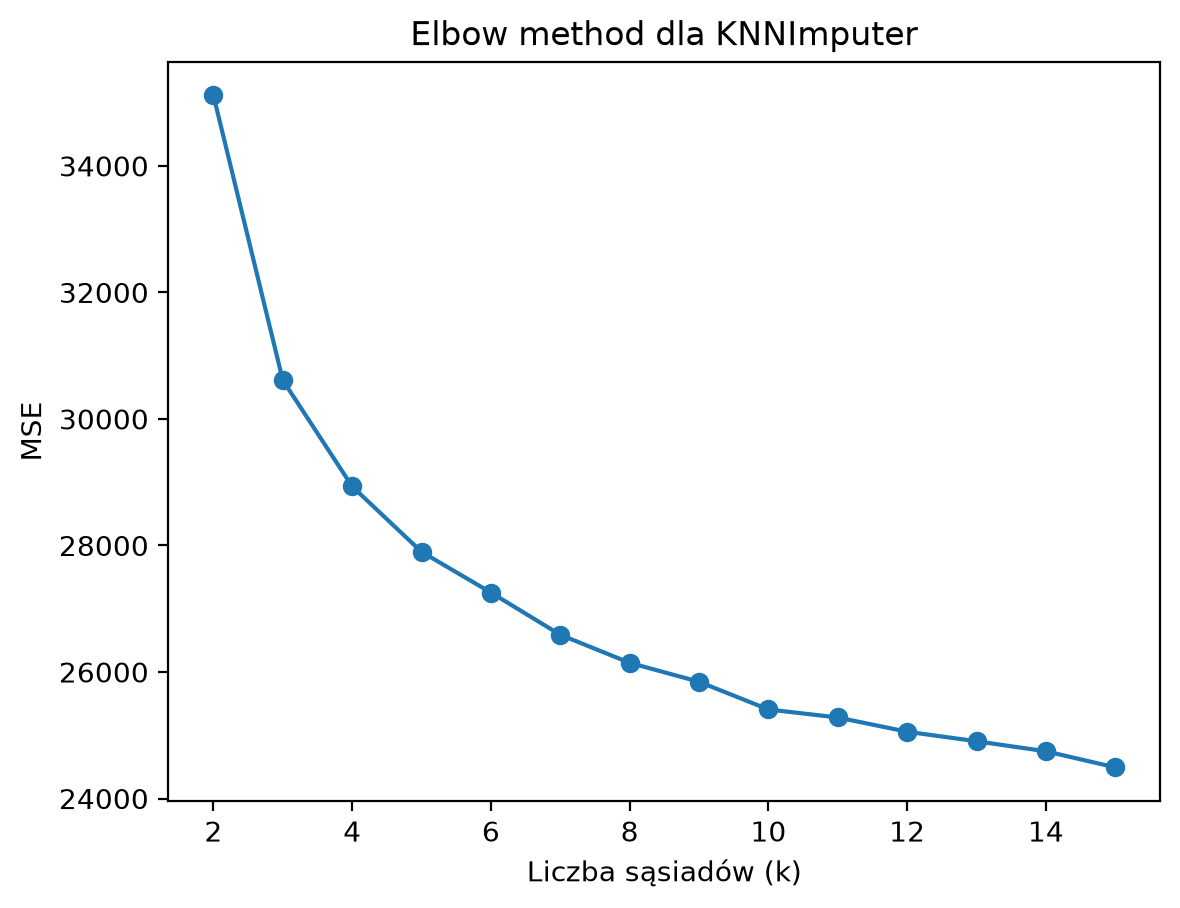

In [9]:
df = dane[['total_bedrooms', 'total_rooms']].dropna().copy()
np.random.seed(42)
mask = np.random.rand(len(df)) < 0.2  
df_missing = df.copy()
df_missing.loc[mask, 'total_bedrooms'] = np.nan
errors = []
neighbors = range(2, 16)
for k in neighbors:
    imputer = KNNImputer(n_neighbors=k)
    imputed = imputer.fit_transform(df_missing)
    mse = mean_squared_error(df['total_bedrooms'][mask], imputed[mask, 0])
    errors.append(mse)

plt.plot(neighbors, errors, marker='o')
plt.xlabel('Liczba sąsiadów (k)')
plt.ylabel('MSE')
plt.title('Elbow method dla KNNImputer')
plt.show()

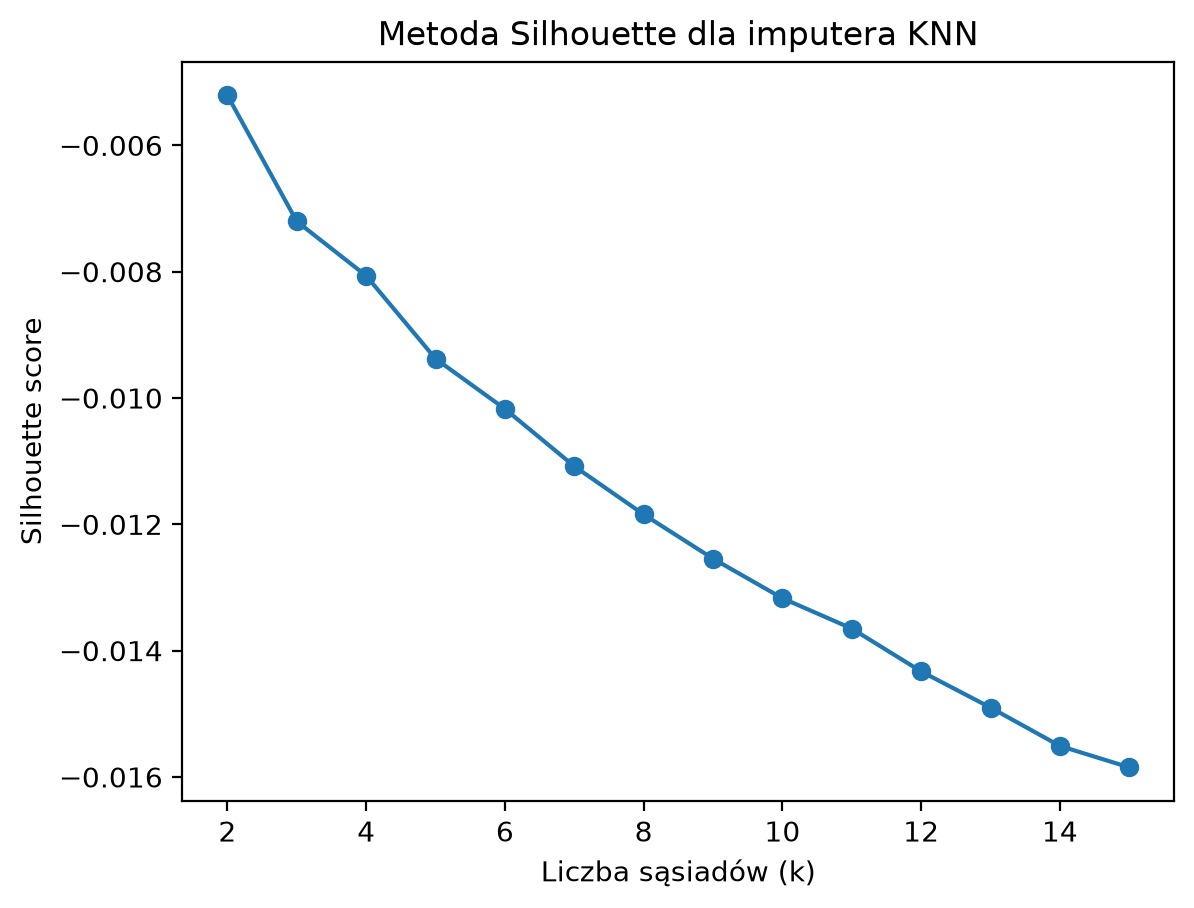

In [10]:
df = dane[['total_bedrooms', 'total_rooms', 'median_income', 'median_house_value']].dropna().copy()
np.random.seed(42)
mask = np.random.rand(len(df)) < 0.2 
df_missing = df.copy()
df_missing.loc[mask, 'total_bedrooms'] = np.nan

silhouette_scores = []
neighbors = range(2, 16)
for k in neighbors:
    imputer = KNNImputer(n_neighbors=k)
    imputed = imputer.fit_transform(df_missing)
    
    scaler = StandardScaler()
    imputed_scaled = scaler.fit_transform(imputed)

    labels = np.where(mask, 1, 0)
    score = silhouette_score(imputed_scaled, labels)
    silhouette_scores.append(score)

plt.plot(neighbors, silhouette_scores, marker='o')
plt.xlabel('Liczba sąsiadów (k)')
plt.ylabel('Silhouette score')
plt.title('Metoda Silhouette dla imputera KNN')
plt.show()

In [11]:
knn_imputer = KNNImputer(n_neighbors=3)  

columns_to_impute = ['total_bedrooms', 'total_rooms']
dane[columns_to_impute] = knn_imputer.fit_transform(dane[columns_to_impute])

dane.isna().any()

longitude             False
latitude              False
housing_median_age    False
total_rooms           False
total_bedrooms        False
population            False
households            False
median_income         False
median_house_value    False
ocean_proximity       False
dtype: bool

In [12]:
dane.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [13]:
def check_rules(df):
    rules = {
        "total_bedrooms >= 0": df["total_bedrooms"] >= 0,
        "total_rooms >= 0": df["total_rooms"] >= 0,
        "population >= 0": df["population"] >= 0,
        "households >= 0": df["households"] >= 0,
        "median_income >= 0": df["median_income"] >= 0,
        "median_house_value >= 0": df["median_house_value"] >= 0,
        "total_bedrooms % 1 == 0": df["total_bedrooms"] % 1 == 0,
        "total_rooms % 1 == 0": df["total_rooms"] % 1 == 0,
        "population % 1 == 0": df["population"] % 1 == 0,
        "households % 1 == 0": df["households"] % 1 == 0,
        "latitude 32 to 42": df["latitude"].between(32, 42),
        "longitude -124 to -114": df["longitude"].between(-124, -114),
    }
    return rules

rules = check_rules(dane)

for rule, result in rules.items():
    print(f"{rule}: {result.all()}")

total_bedrooms >= 0: True
total_rooms >= 0: True
population >= 0: True
households >= 0: True
median_income >= 0: True
median_house_value >= 0: True
total_bedrooms % 1 == 0: False
total_rooms % 1 == 0: True
population % 1 == 0: True
households % 1 == 0: True
latitude 32 to 42: True
longitude -124 to -114: False


In [14]:

violations = {rule: ~result for rule, result in rules.items()}
summary = {rule: result.sum() for rule, result in violations.items()}
print("Summary of Violations:")
for rule, count in summary.items():
    print(f"{rule}: {count} violations")

Summary of Violations:
total_bedrooms >= 0: 0 violations
total_rooms >= 0: 0 violations
population >= 0: 0 violations
households >= 0: 0 violations
median_income >= 0: 0 violations
median_house_value >= 0: 0 violations
total_bedrooms % 1 == 0: 137 violations
total_rooms % 1 == 0: 0 violations
population % 1 == 0: 0 violations
households % 1 == 0: 0 violations
latitude 32 to 42: 0 violations
longitude -124 to -114: 121 violations


In [15]:
violations = {rule: ~result for rule, result in rules.items()}
violated_df = pd.DataFrame(violations)
violated_rows = dane[violated_df["total_bedrooms % 1 == 0"]]
print(violated_rows)

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
290      -122.16     37.77                47.0       1256.0      242.666667   
538      -122.28     37.78                29.0       5154.0     1117.666667   
563      -122.24     37.75                45.0        891.0      184.333333   
738      -122.14     37.67                37.0       3342.0      711.666667   
1097     -121.77     39.66                20.0       3759.0      662.666667   
...          ...       ...                 ...          ...             ...   
19959    -119.32     36.25                21.0       1231.0      272.333333   
20069    -120.37     38.01                30.0        473.0      121.333333   
20267    -119.19     34.20                18.0       3620.0      713.666667   
20372    -118.88     34.17                15.0       4260.0      689.333333   
20484    -118.72     34.28                17.0       3051.0      586.666667   

       population  households  median_income  media

In [16]:
dane['total_bedrooms'] = dane['total_bedrooms'].round(0)
rules = check_rules(dane)

for rule, result in rules.items():
    print(f"{rule}: {result.all()}")

total_bedrooms >= 0: True
total_rooms >= 0: True
population >= 0: True
households >= 0: True
median_income >= 0: True
median_house_value >= 0: True
total_bedrooms % 1 == 0: True
total_rooms % 1 == 0: True
population % 1 == 0: True
households % 1 == 0: True
latitude 32 to 42: True
longitude -124 to -114: False


In [17]:
violations = {rule: ~result for rule, result in rules.items()}
violated_df = pd.DataFrame(violations)
violated_rows = dane[violated_df["longitude -124 to -114"]]
print(violated_rows)

      longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
1850    -124.17     41.80                16.0       2739.0           480.0   
1851    -124.30     41.80                19.0       2672.0           552.0   
1852    -124.23     41.75                11.0       3159.0           616.0   
1853    -124.21     41.77                17.0       3461.0           722.0   
1854    -124.19     41.78                15.0       3140.0           714.0   
...         ...       ...                 ...          ...             ...   
2653    -124.26     40.58                52.0       2217.0           394.0   
2654    -124.23     40.54                52.0       2694.0           453.0   
2655    -124.35     40.54                52.0       1820.0           300.0   
2656    -124.25     40.28                32.0       1430.0           419.0   
2657    -124.08     40.06                17.0       1319.0           267.0   

      population  households  median_income  median_house_value

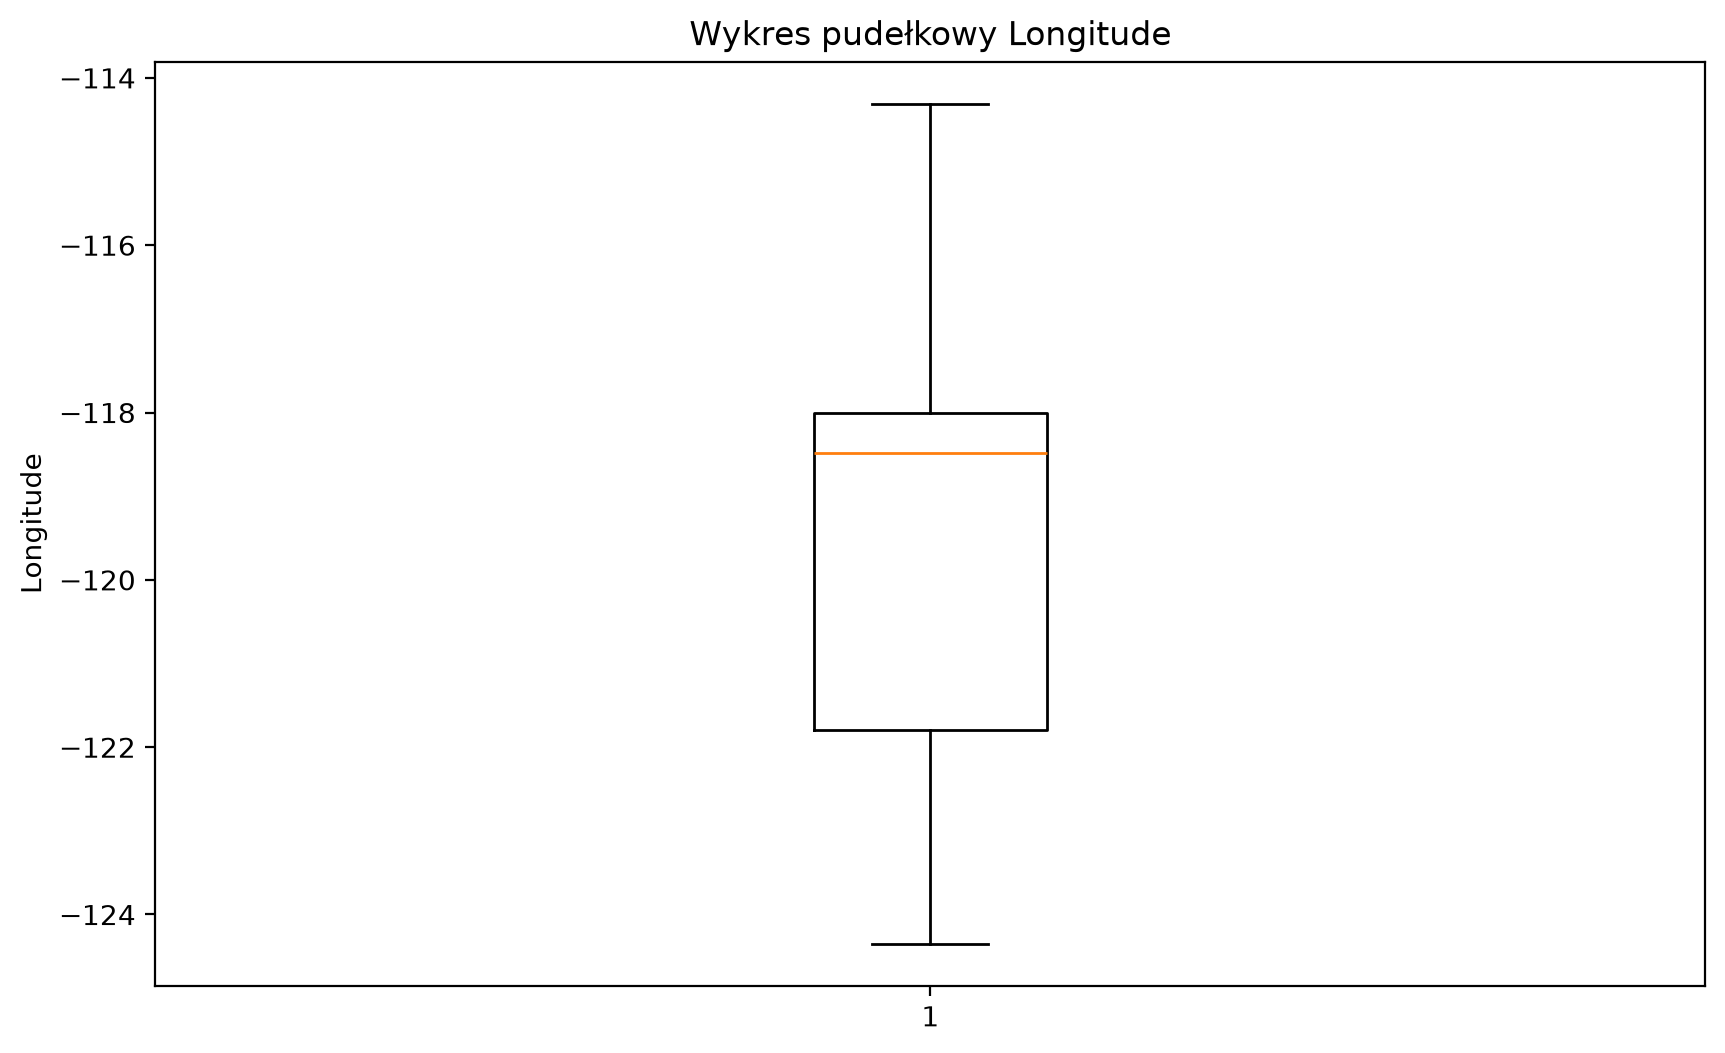

Odstające:
       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
1850     -124.17     41.80                16.0       2739.0           480.0   
1851     -124.30     41.80                19.0       2672.0           552.0   
1852     -124.23     41.75                11.0       3159.0           616.0   
1853     -124.21     41.77                17.0       3461.0           722.0   
1854     -124.19     41.78                15.0       3140.0           714.0   
...          ...       ...                 ...          ...             ...   
19802    -123.17     40.31                36.0         98.0            28.0   
19803    -123.22     40.16                27.0       1848.0           449.0   
19804    -123.48     40.34                19.0        518.0           108.0   
19805    -123.43     40.22                20.0        133.0            35.0   
19806    -123.41     40.07                17.0        449.0           151.0   

       population  households  median_in

In [18]:
plt.figure(figsize=(10, 6))
plt.boxplot(dane['longitude'].dropna())
plt.title('Wykres pudełkowy Longitude')
plt.ylabel('Longitude')
plt.show()

outliers = dane['longitude'][np.abs(dane['longitude'] - dane['longitude'].mean()) > (1.5 * dane['longitude'].std())]
outliers_idx = dane.index[dane['longitude'].isin(outliers)]

# Wydrukujemy je:
print("Odstające:")
print(dane.loc[outliers_idx])

In [19]:
dane['total_bedrooms'] = dane['total_bedrooms'].astype(int)
dane['total_rooms'] = dane['total_rooms'].astype(int)
dane['population'] = dane['population'].astype(int)
dane['households'] = dane['households'].astype(int)
dane.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20640 non-null  int64  
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(5), int64(4), str(1)
memory usage: 1.6 MB


In [20]:
dane['median_house_value'] = (dane['median_house_value']/10000).round(4)

In [21]:
print(dane['ocean_proximity'].unique())

<StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str


In [22]:
print(dane['ocean_proximity'].value_counts())

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


In [23]:
dane['ocean_proximity'] = dane['ocean_proximity'].replace({'ISLAND': 'NEAR OCEAN'})
print(dane['ocean_proximity'].value_counts())

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2663
NEAR BAY      2290
Name: count, dtype: int64


In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
dane

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880,129,322,126,8.3252,45.26,NEAR BAY
1,-122.22,37.86,21.0,7099,1106,2401,1138,8.3014,35.85,NEAR BAY
2,-122.24,37.85,52.0,1467,190,496,177,7.2574,35.21,NEAR BAY
3,-122.25,37.85,52.0,1274,235,558,219,5.6431,34.13,NEAR BAY
4,-122.25,37.85,52.0,1627,280,565,259,3.8462,34.22,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665,374,845,330,1.5603,7.81,INLAND
20636,-121.21,39.49,18.0,697,150,356,114,2.5568,7.71,INLAND
20637,-121.22,39.43,17.0,2254,485,1007,433,1.7000,9.23,INLAND
20638,-121.32,39.43,18.0,1860,409,741,349,1.8672,8.47,INLAND


In [26]:
dane['bedrooms_per_room'] = (dane['total_bedrooms'] / dane['total_rooms']).round(2)
dane['population_per_household'] = (dane['population'] / dane['households']).round(2)
dane['rooms_per_household'] = (dane['total_rooms'] / dane['households']).round(2)
dane['bedrooms_per_person'] = (dane['total_bedrooms'] / dane['population']).round(2)
dane['price_to_monthly_income_ratio'] = (dane['median_house_value'] / dane['median_income']).round(2)

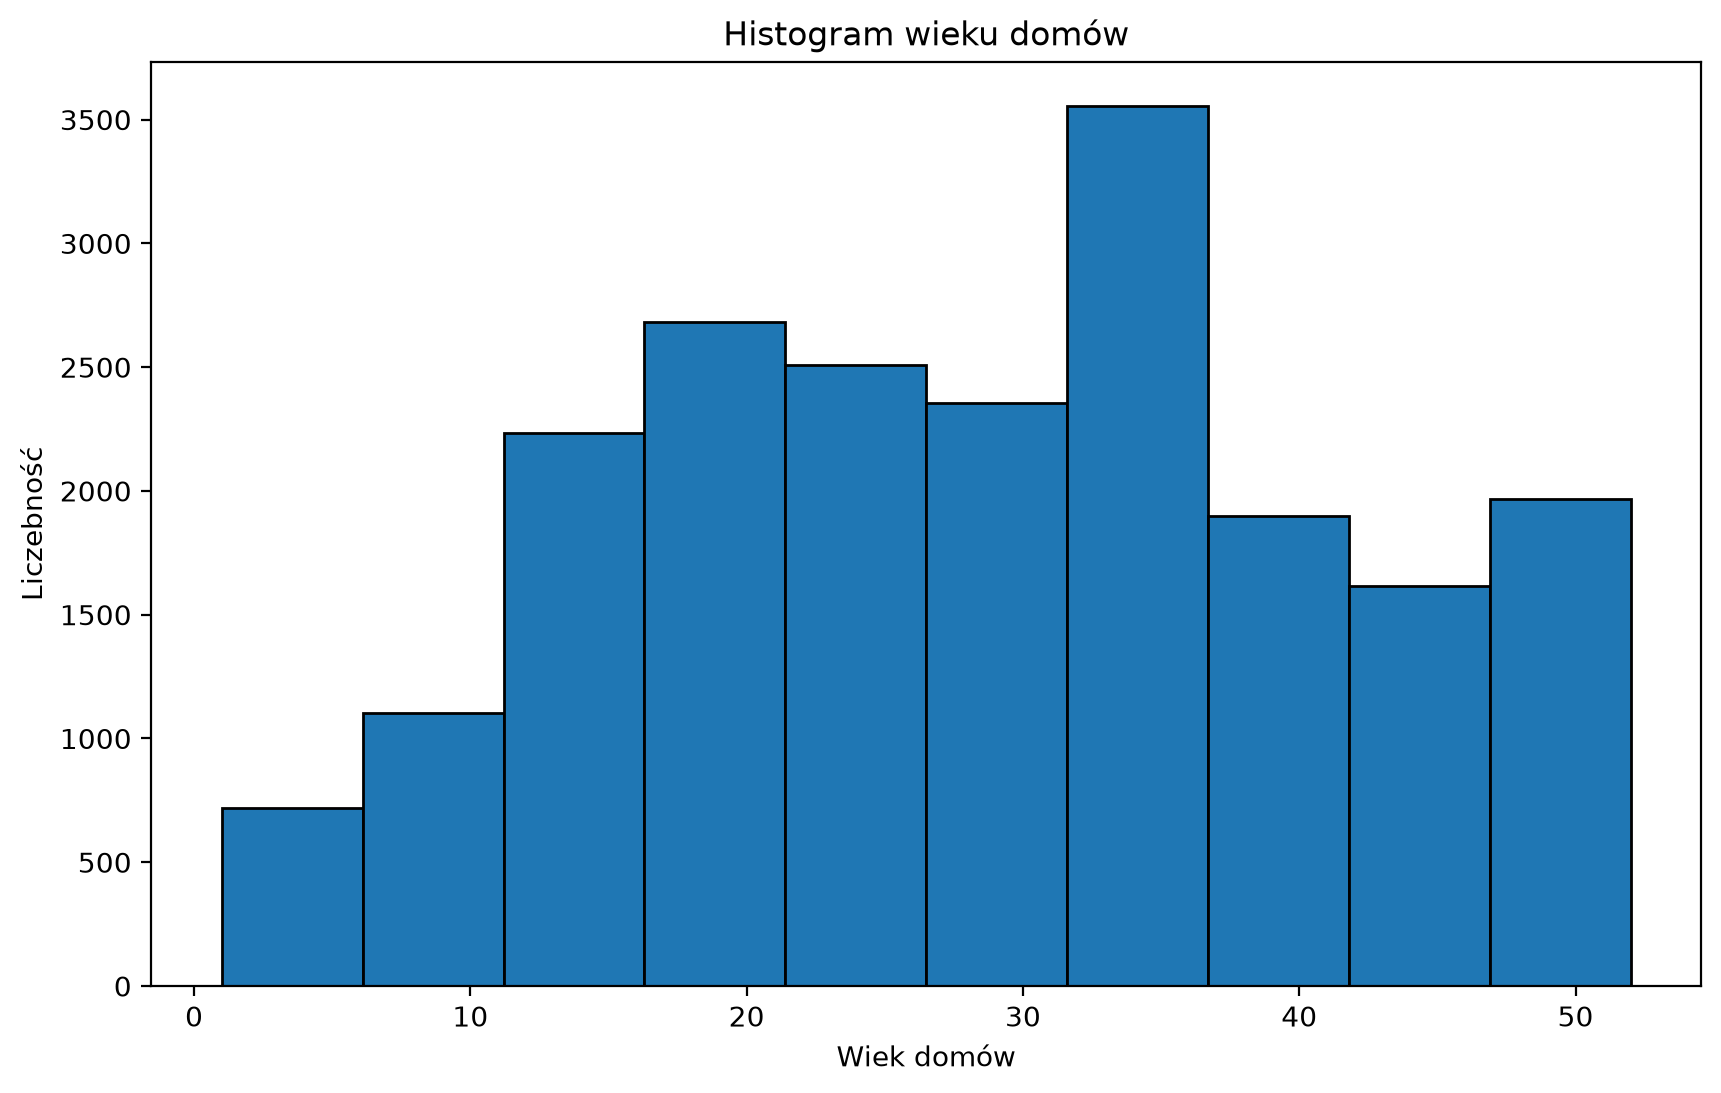

In [27]:
plt.figure(figsize=(10, 6))
plt.hist(dane['housing_median_age'], edgecolor='black')
plt.title('Histogram wieku domów')
plt.xlabel('Wiek domów')
plt.ylabel('Liczebność')
plt.show()

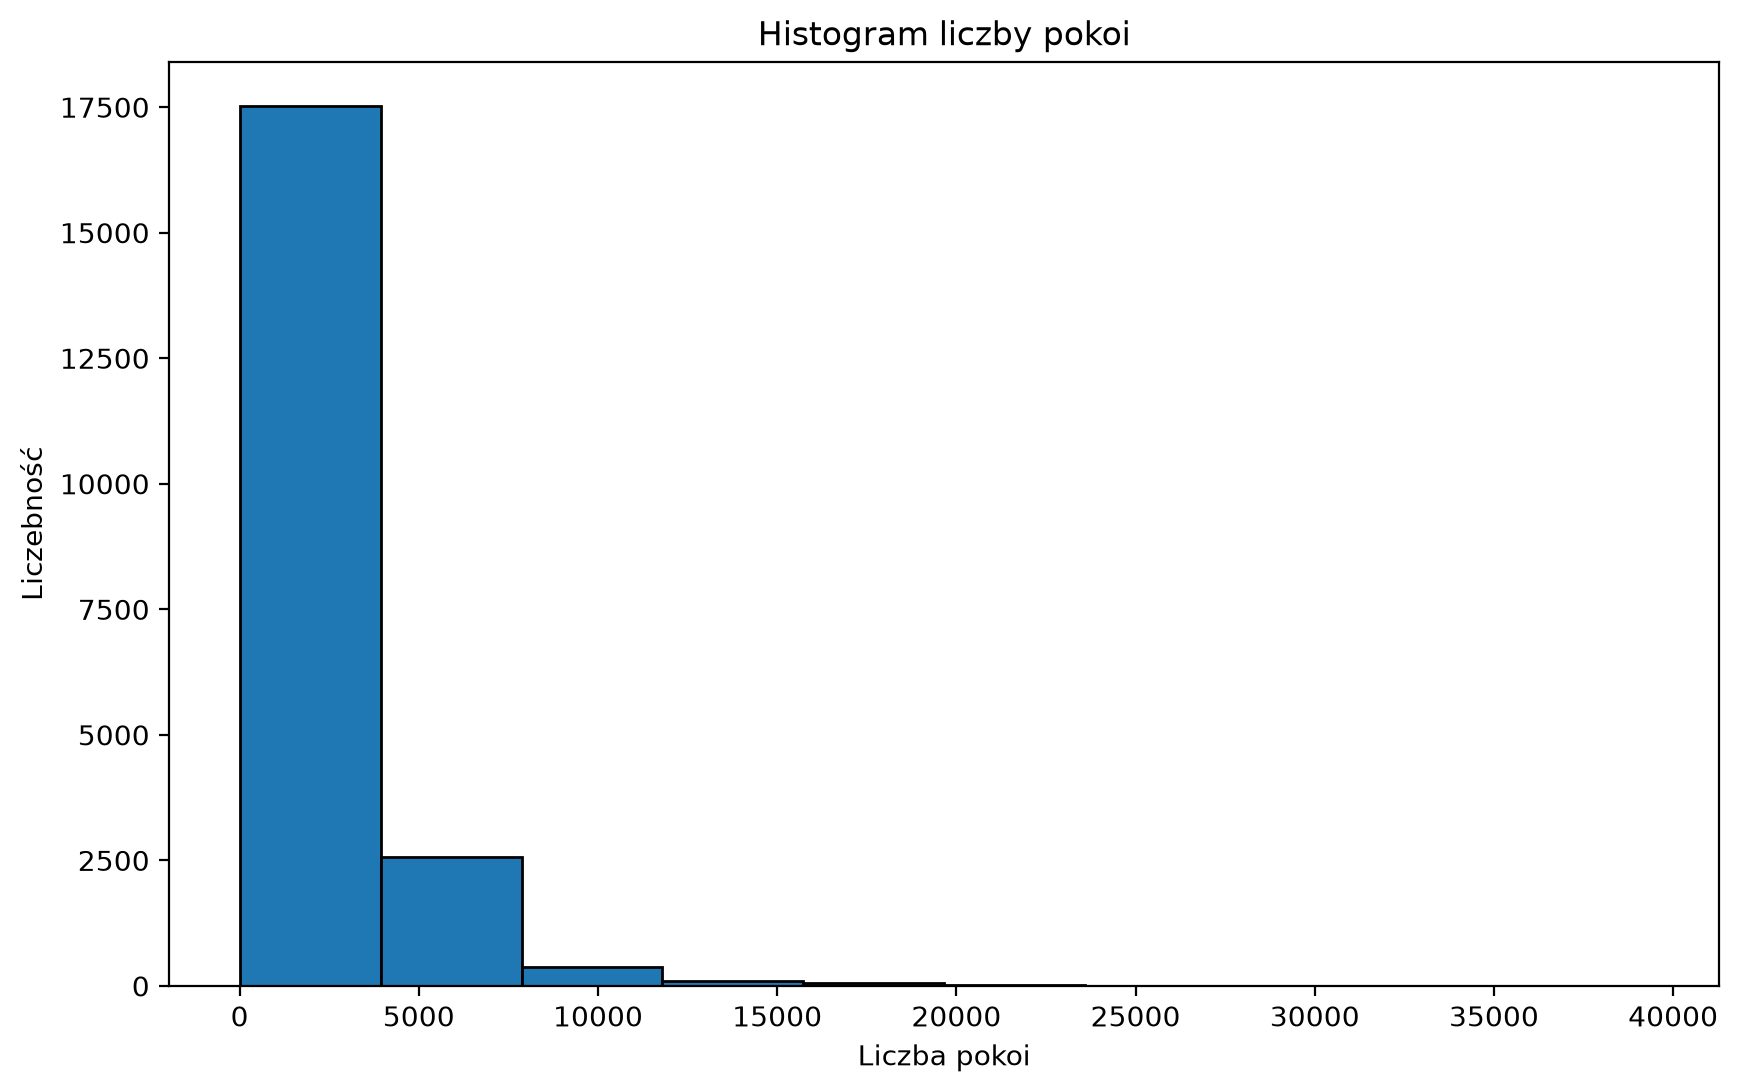

In [28]:
plt.figure(figsize=(10, 6))
plt.hist(dane['total_rooms'], edgecolor='black')
plt.title('Histogram liczby pokoi')
plt.xlabel('Liczba pokoi')
plt.ylabel('Liczebność')
plt.show()

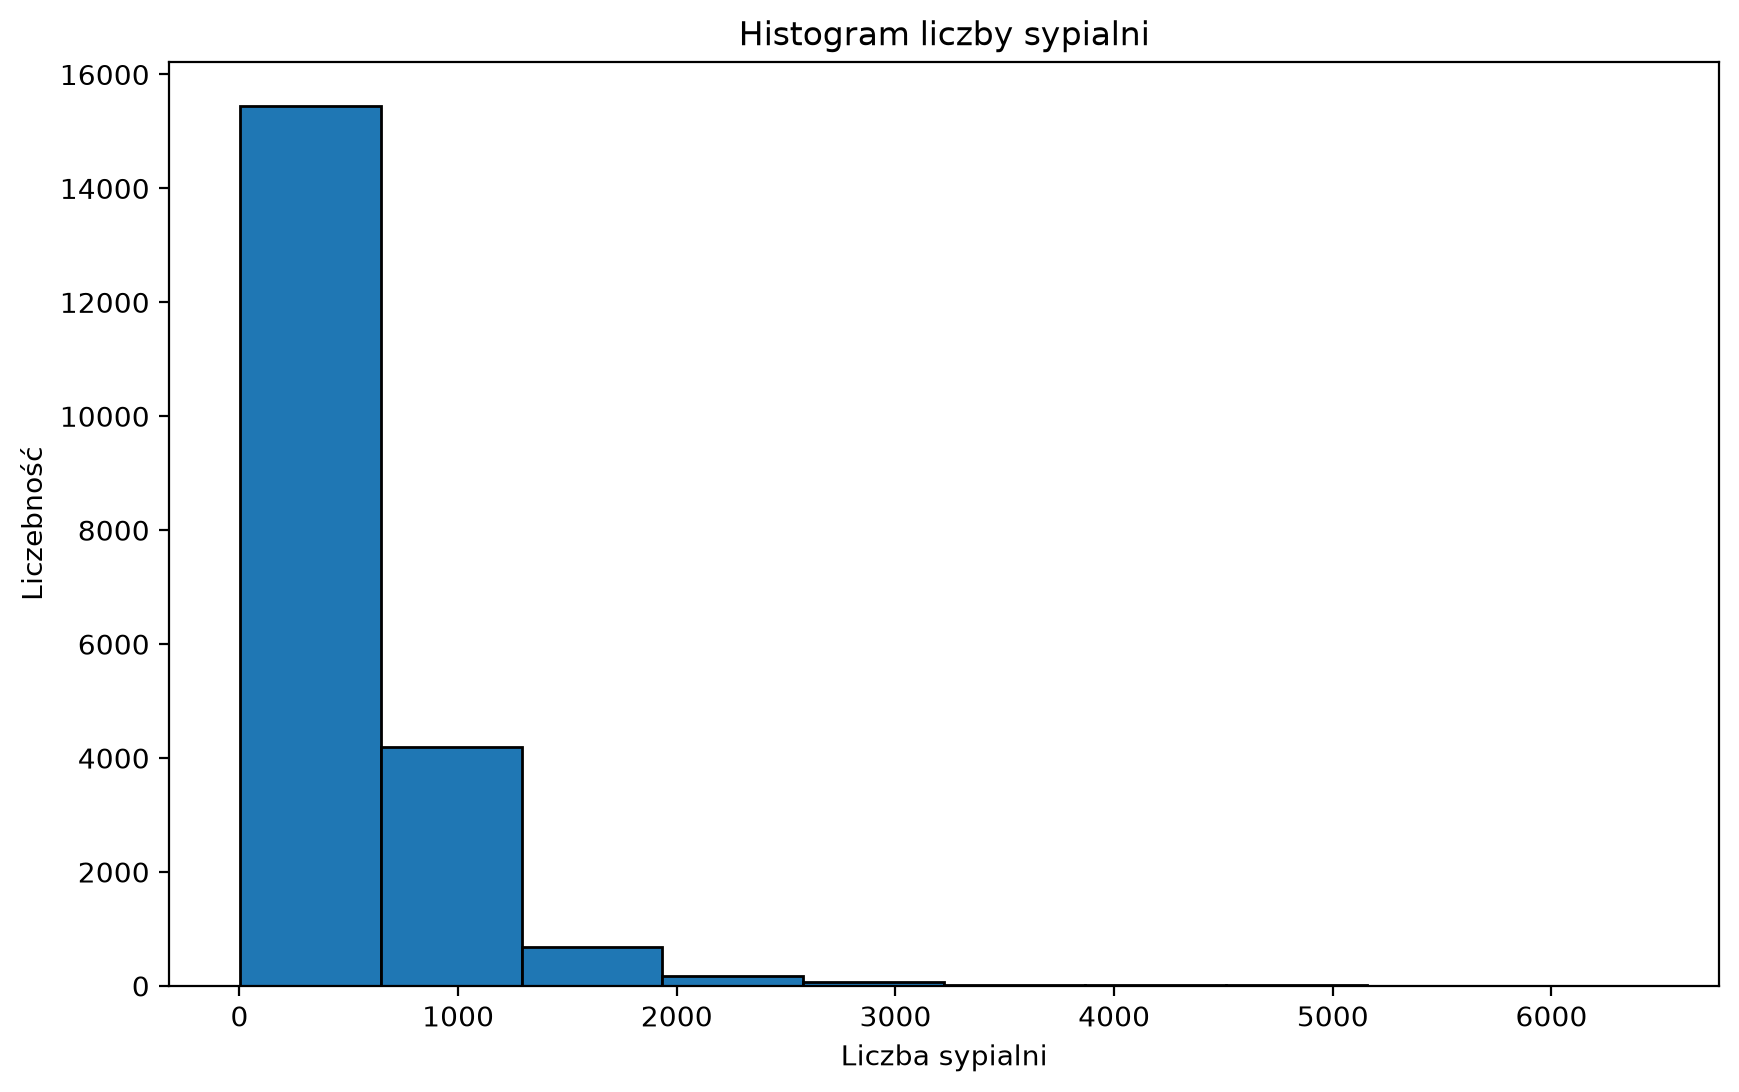

In [29]:
plt.figure(figsize=(10, 6))
plt.hist(dane['total_bedrooms'], edgecolor='black')
plt.title('Histogram liczby sypialni')
plt.xlabel('Liczba sypialni')
plt.ylabel('Liczebność')
plt.show()

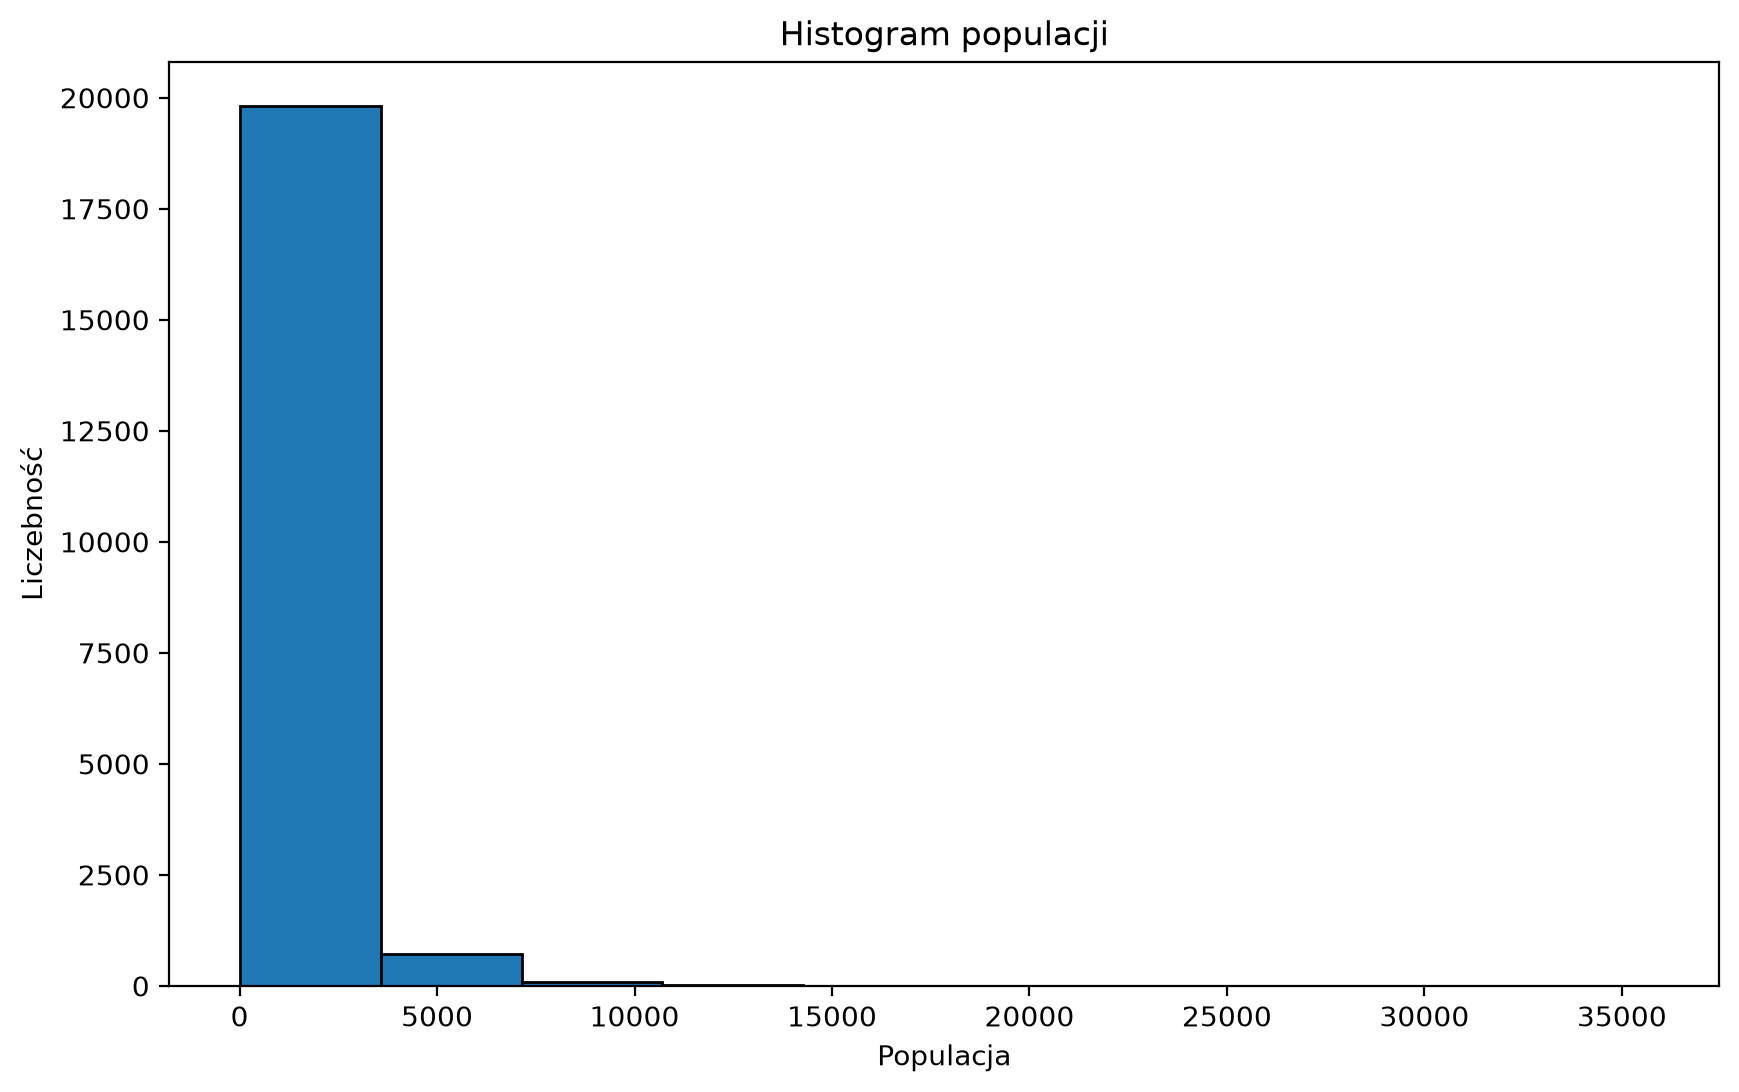

In [30]:
plt.figure(figsize=(10, 6))
plt.hist(dane['population'], edgecolor='black')
plt.title('Histogram populacji')
plt.xlabel('Populacja')
plt.ylabel('Liczebność')
plt.show()

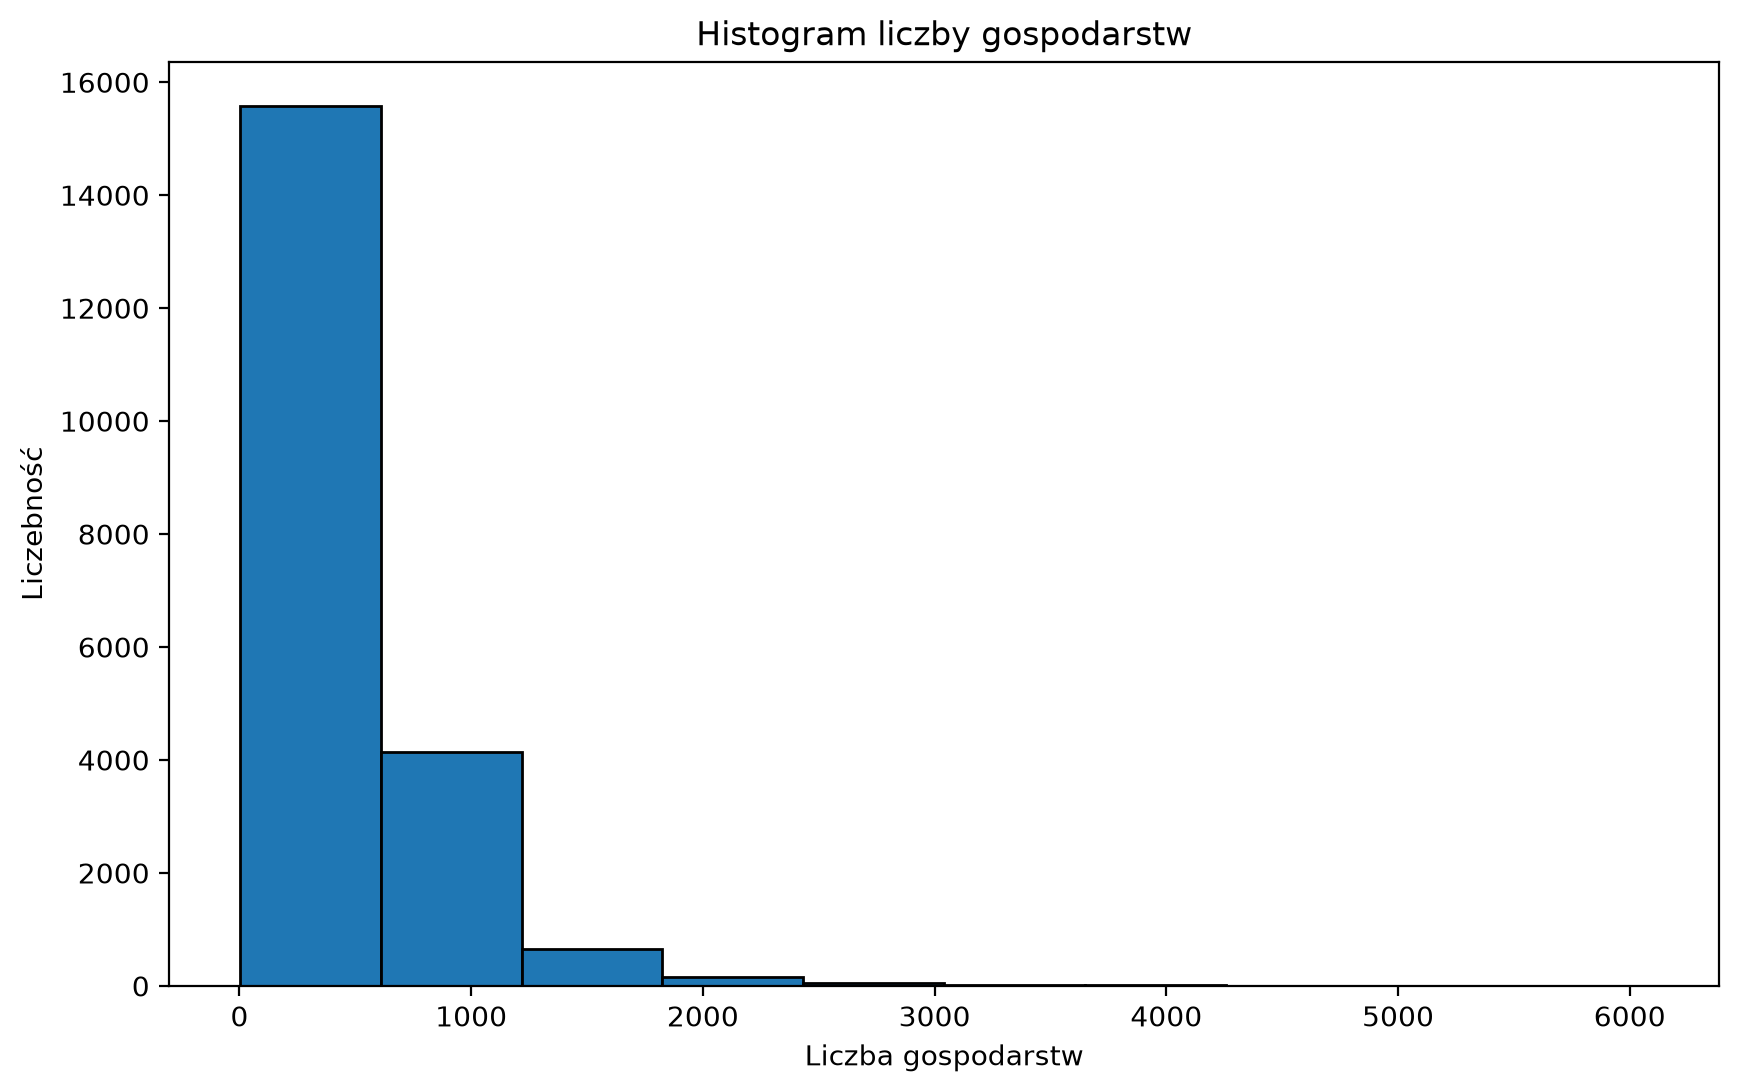

In [31]:
plt.figure(figsize=(10, 6))
plt.hist(dane['households'], edgecolor='black')
plt.title('Histogram liczby gospodarstw')
plt.xlabel('Liczba gospodarstw')
plt.ylabel('Liczebność')
plt.show()

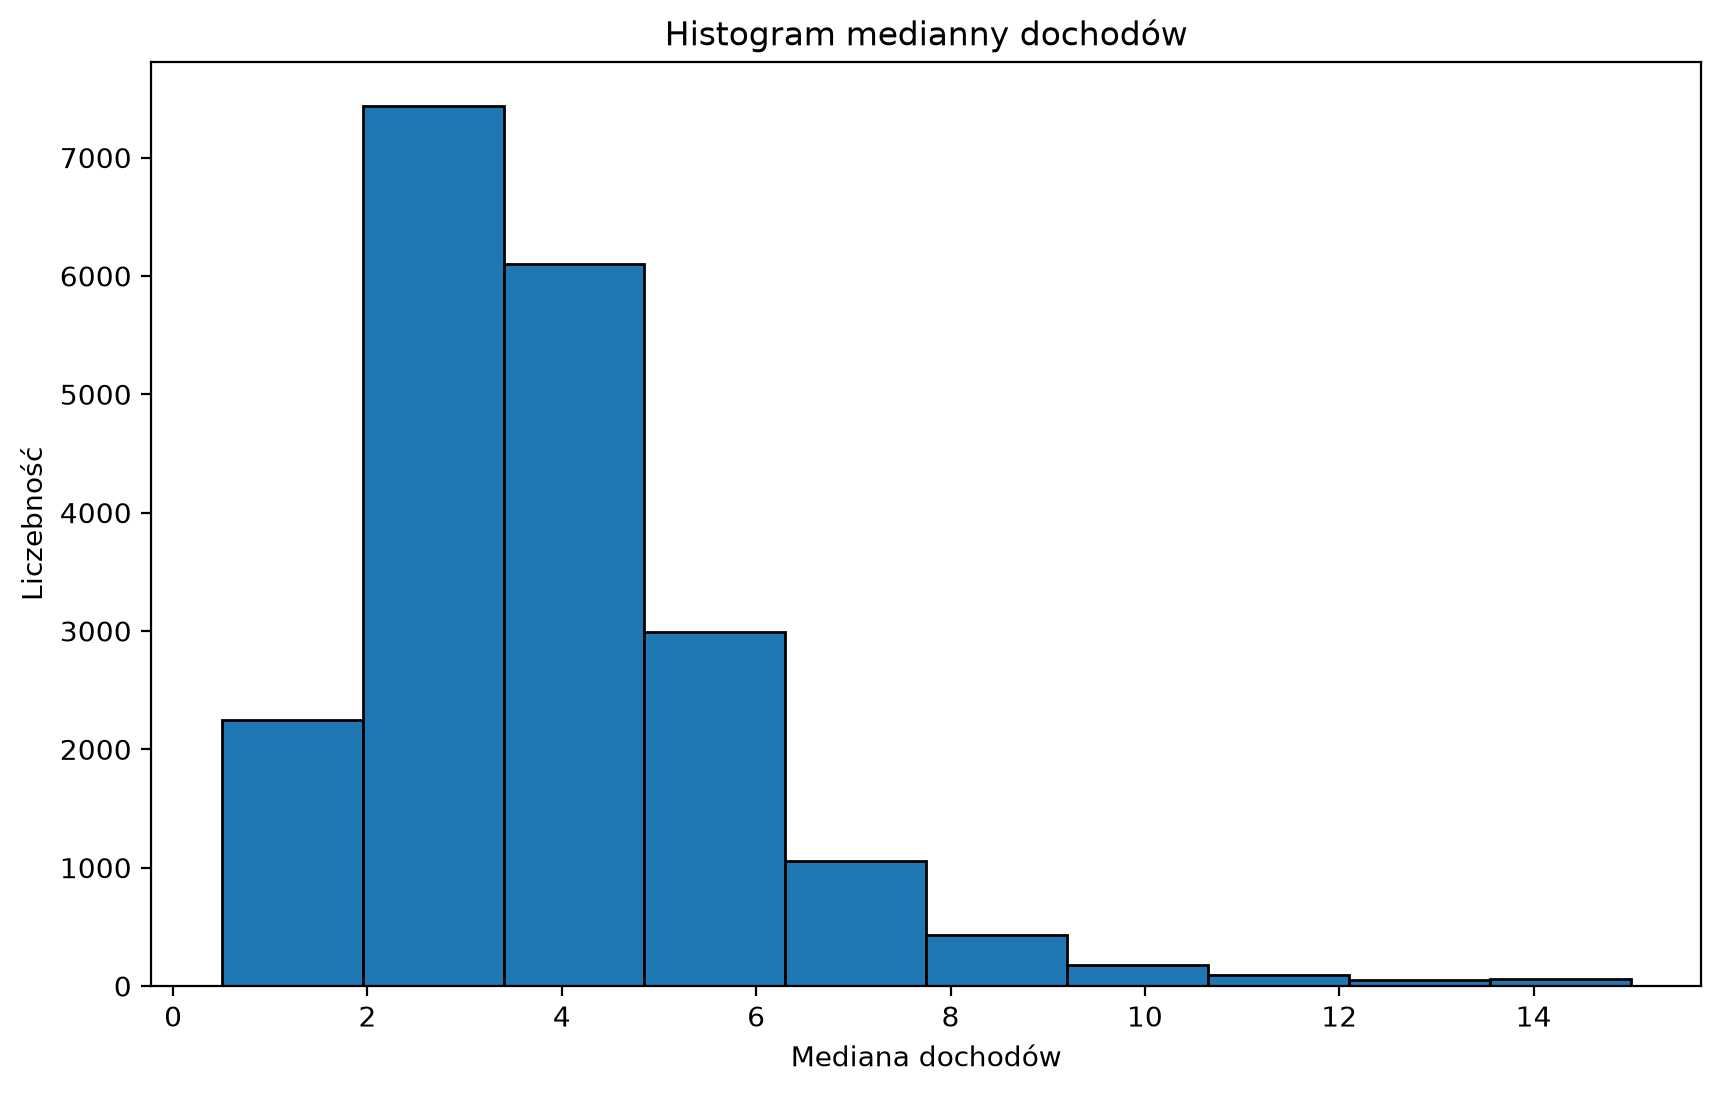

In [32]:
plt.figure(figsize=(10, 6))
plt.hist(dane['median_income'], edgecolor='black')
plt.title('Histogram medianny dochodów')
plt.xlabel('Mediana dochodów')
plt.ylabel('Liczebność')
plt.show()

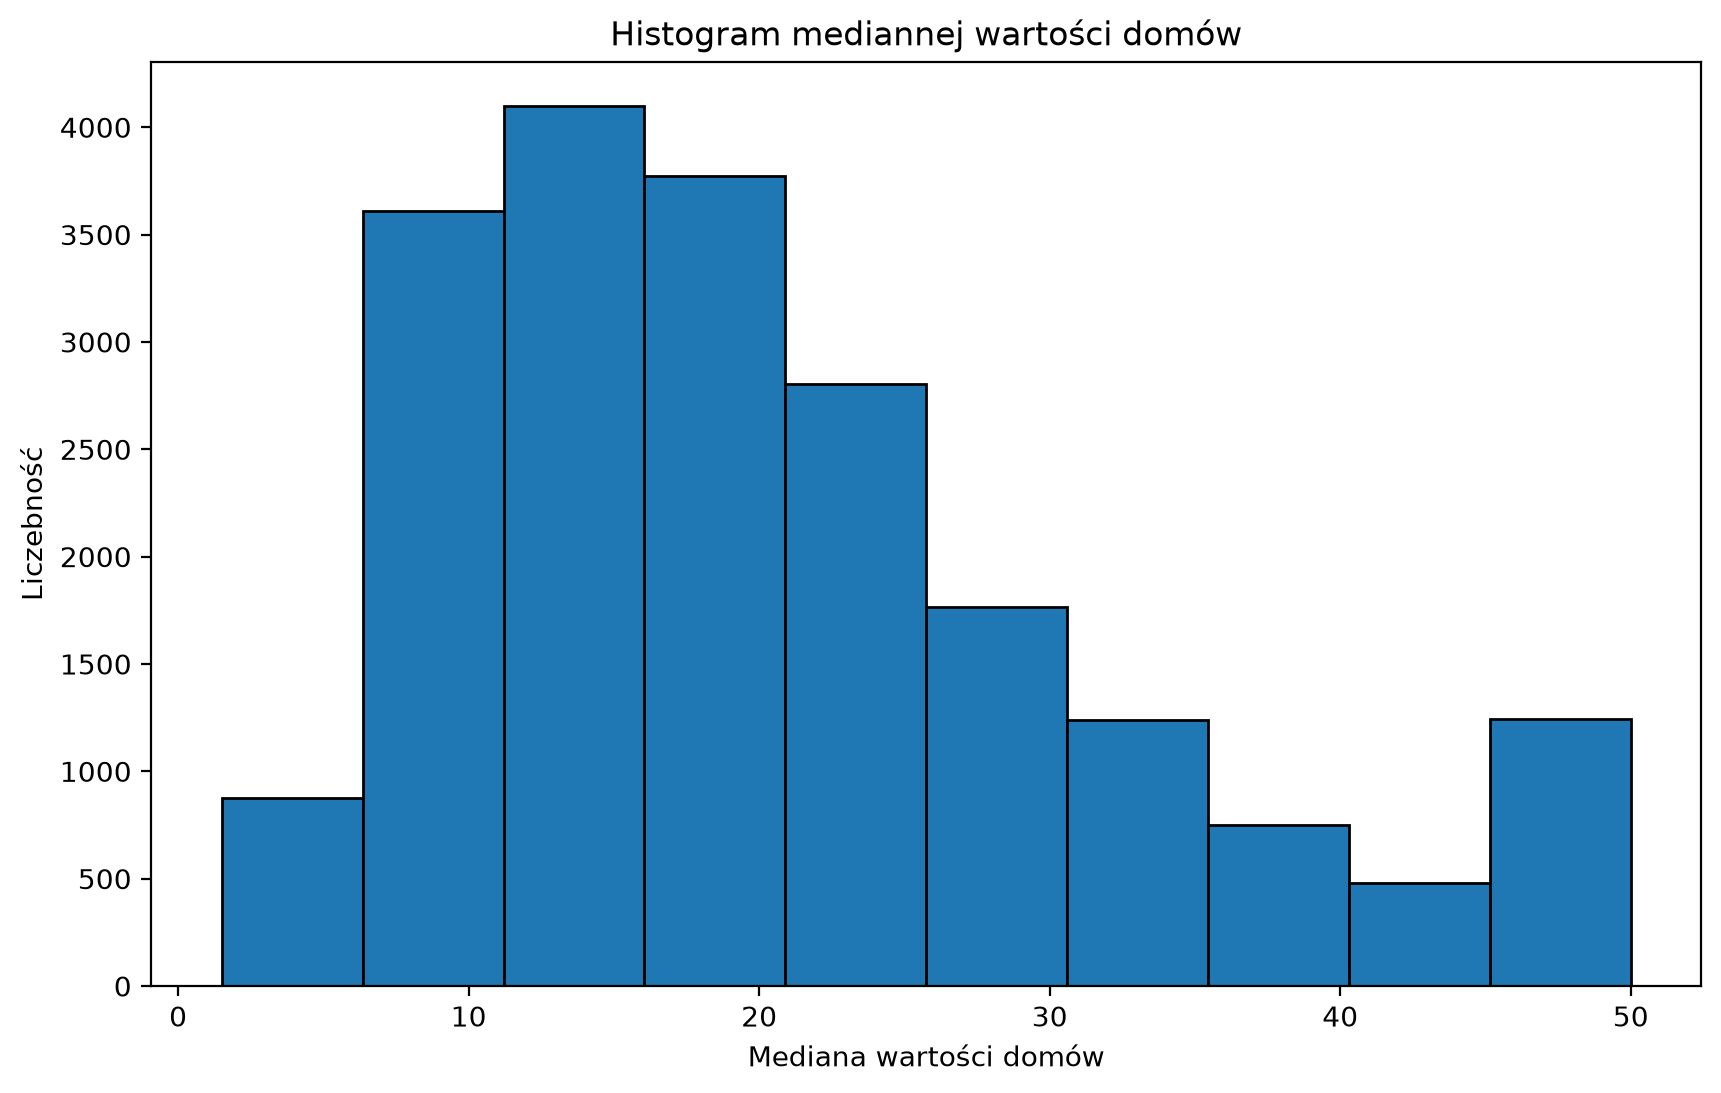

In [33]:
plt.figure(figsize=(10, 6))
plt.hist(dane['median_house_value'], edgecolor='black')
plt.title('Histogram mediannej wartości domów')
plt.xlabel('Mediana wartości domów')
plt.ylabel('Liczebność')
plt.show()

In [36]:
dane['total_rooms_log'] = np.log(dane['total_rooms'])
dane['total_bedrooms_log'] = np.log(dane['total_bedrooms'])
dane['population_log'] = np.log(dane['population'])
dane['households_log'] = np.log(dane['households'])
dane['median_income_log'] = np.log(dane['median_income'])

dane['population_per_household_log'] = np.log(dane['population_per_household'])
dane['rooms_per_household_log'] = np.log(dane['rooms_per_household'])
dane['bedrooms_per_person_log'] = np.log1p(dane['bedrooms_per_person'])
dane['price_to_monthly_income_ratio_log'] = np.log(dane['price_to_monthly_income_ratio'])

In [ ]:
dane

In [34]:
dane

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,bedrooms_per_room,population_per_household,rooms_per_household,bedrooms_per_person,price_to_monthly_income_ratio
0,-122.23,37.88,41.0,880,129,322,126,8.3252,45.26,NEAR BAY,0.15,2.56,6.98,0.40,5.44
1,-122.22,37.86,21.0,7099,1106,2401,1138,8.3014,35.85,NEAR BAY,0.16,2.11,6.24,0.46,4.32
2,-122.24,37.85,52.0,1467,190,496,177,7.2574,35.21,NEAR BAY,0.13,2.80,8.29,0.38,4.85
3,-122.25,37.85,52.0,1274,235,558,219,5.6431,34.13,NEAR BAY,0.18,2.55,5.82,0.42,6.05
4,-122.25,37.85,52.0,1627,280,565,259,3.8462,34.22,NEAR BAY,0.17,2.18,6.28,0.50,8.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665,374,845,330,1.5603,7.81,INLAND,0.22,2.56,5.05,0.44,5.01
20636,-121.21,39.49,18.0,697,150,356,114,2.5568,7.71,INLAND,0.22,3.12,6.11,0.42,3.02
20637,-121.22,39.43,17.0,2254,485,1007,433,1.7000,9.23,INLAND,0.22,2.33,5.21,0.48,5.43
20638,-121.32,39.43,18.0,1860,409,741,349,1.8672,8.47,INLAND,0.22,2.12,5.33,0.55,4.54
